# TSViT + LLM — Clasificacion de Cultivos en PASTIS24

## Arquitectura

```
Encoder (TSViT)                               Decoder (LLM)
                                               Qwen2.5-3B + LoRA
Input: PASTIS24 pickle                    
  img: (T, 10, 24, 24) int16                  Word Embeddings
  doy: (T,) int64                                  |
  labels: (3, 24, 24) uint8                    Masked Multi-Head Attention
       |                                            |
  Normalize + prepend time channel             Feed Forward
  -> (T, 11, 24, 24)                               |
       |                                       Linear -> Softmax
  Patch Embeddings                                  |
       |                                       "Soft winter wheat"
  Temporal Encoder (6 layers, d=128)
  + K=18 CLS tokens
       |
  Spatial Encoder (2 layers, d=128)    Projector (Adapter)
       |                               MLP: 128 -> 2048 -> 2048
  K=18 CLS token outputs (K, 128) --->      |
                                        visual tokens -> LLM
```

### Dataset: PASTIS24
Formato pre-procesado del repo TSViT (DeepSatModels, CVPR 2023).
Los patches 128x128 originales ya vienen divididos en ventanas 24x24.

| Contenido | Shape | Descripcion |
|-----------|-------|-------------|
| `img` | (T, 10, 24, 24) int16 | 10 bandas S2, T fechas |
| `doy` | (T,) int64 | Dia del anio por fecha |
| `labels` | (3, 24, 24) uint8 | Segmentacion semantica |

### Entrenamiento en 2 etapas
| Etapa | Que se entrena | Loss |
|-------|---------------|------|
| Stage 1 | TSViT completo | Focal Loss |
| Stage 2 | Projector + LoRA (TSViT frozen) | Cross-Entropy LM |

### VRAM estimado (RTX 5080 16GB)
| Componente | VRAM |
|-----------|------|
| TSViT encoder (~2M params) | ~0.1 GB |
| Projector MLP (~5M params) | ~0.01 GB |
| Qwen2.5-3B (4-bit + LoRA) | ~3.5 GB |
| Activations + optimizer | ~4-5 GB |
| **Total** | **~8 GB** |

### Fuentes
| Componente | Paper/Repo |
|-----------|------------|
| TSViT | Tarasiou et al., CVPR 2023 — github.com/michaeltrs/DeepSatModels |
| PASTIS | Garnot & Landrieu, 2022 — github.com/VSainteuf/pastis-benchmark |
| Projector | LLaVA, Liu et al. 2023 — arxiv.org/abs/2304.08485 |
| LoRA | Hu et al., ICLR 2022 — arxiv.org/abs/2106.09685 |

In [1]:
# ============================================================
# Celda 1: Instalacion de dependencias (uv)
# ============================================================
import subprocess

deps = [
    "torch", "torchvision", "torchaudio",
    "einops",
    "transformers>=4.45.0", "accelerate", "bitsandbytes", "peft",
    "sentencepiece", "protobuf",
    "numpy", "matplotlib", "tqdm", "scikit-learn", "pandas",
]

for dep in deps:
    subprocess.check_call(["uv", "add", dep])
print("Dependencias instaladas con uv")

Dependencias instaladas con uv


In [2]:
# ============================================================
# Celda 2: Imports y configuracion
# ============================================================
import os, pickle, glob, random, math, gc, warnings, json, tempfile
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# -- Paths --
_ROOT = Path.cwd().parent if Path.cwd().name == "reports" else Path.cwd()
PASTIS24_DIR = _ROOT / "dataset" / "PASTIS24"
PICKLE_DIR = PASTIS24_DIR / "pickle24x24"
FOLDS_DIR = PASTIS24_DIR / "fold-paths"

# -- Clases (1-18, same as PASTIS) --
CLASSES = {
    1: "Meadow", 2: "Soft_winter_wheat", 3: "Corn",
    4: "Winter_barley", 5: "Winter_rapeseed", 6: "Spring_barley",
    7: "Sunflower", 8: "Grapevine", 9: "Beet", 10: "Winter_triticale",
    11: "Winter_durum_wheat", 12: "Fruits_vegetables_flowers", 13: "Potatoes",
    14: "Leguminous_fodder", 15: "Soybeans", 16: "Orchard",
    17: "Mixed_cereal", 18: "Sorghum"
}
NUM_CLASSES = 18

# -- Hiperparametros TSViT (CVPR 2023 paper Table 2) --
IMG_RES = 24
PATCH_SIZE = 2
MAX_SEQ_LEN = 60
DIM = 128
TEMPORAL_DEPTH = 6
SPATIAL_DEPTH = 2
HEADS = 8
DIM_HEAD = DIM // HEADS

# -- Training config --
BATCH_SIZE = 64              # H100 100GB: sin restricción de VRAM
ACCUM_STEPS = 2              # effective batch = 128
LR_STAGE1 = 1e-3             # batch grande → LR más alto (scaling lineal)
LR_PROJECTOR = 1e-3
LR_LORA = 2e-4
NUM_EPOCHS_STAGE1 = 50       # más epochs con augmentation converge más lento
NUM_EPOCHS_STAGE2 = 15
WARMUP_EPOCHS = 5
PATIENCE = 12                # early stopping
USE_AMP = True               # bf16 en H100
NUM_WORKERS = 0

# -- LLM config --
LLM_NAME = "Qwen/Qwen2.5-3B-Instruct"

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name()}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   VRAM: {vram:.1f} GB")
print(f"PASTIS24: {PASTIS24_DIR}")
print(f"   pickle24x24: {'OK' if PICKLE_DIR.is_dir() else 'NOT FOUND'}")
print(f"   fold-paths:  {'OK' if FOLDS_DIR.is_dir() else 'NOT FOUND'}")
print(f"{NUM_CLASSES} clases de cultivos")

Device: cuda
   GPU: NVIDIA H100 NVL
   VRAM: 100.1 GB
PASTIS24: F:\projects\crop_clip\dataset\PASTIS24
   pickle24x24: OK
   fold-paths:  OK
18 clases de cultivos


## Carga de datos PASTIS24

Dataset pre-procesado del repo TSViT (DeepSatModels):
- Cada `.pickle` contiene `img` (T, 10, 24, 24), `doy` (T,), `labels` (3, 24, 24)
- Splits oficiales en `fold-paths/fold_{n}_paths.csv`
- Normalizacion: `img / 10000`, clip [0, 1]
- Canal de tiempo: `doy / 365` broadcast a (T, 1, 24, 24)
- Label: clase mayoritaria de `labels[0]` (semantic mask)

In [3]:
# ============================================================
# Celda 3: Carga directa desde PASTIS24 pickles
# Formato: pickle24x24/{patchID}_{windowIdx}.pickle
#   img:    (T, 10, 24, 24) int16
#   doy:    (T,) int64
#   labels: (3, 24, 24) uint8 -> [semantic, instance, ...]
# ============================================================

def load_pickle_sample(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data

def get_majority_class(semantic_mask):
    """Clase mayoritaria de la mascara semantica 24x24."""
    flat = semantic_mask.flatten()
    flat = flat[flat > 0]  # Ignorar background (0)
    flat = flat[flat <= 18]  # Solo clases validas (1-18)
    if len(flat) == 0:
        return 0  # Sin clase valida
    return int(np.bincount(flat).argmax())

def load_fold_paths(folds_dir, fold_num):
    """Lee paths de un fold CSV."""
    csv_path = folds_dir / f"fold_{fold_num}_paths.csv"
    if not csv_path.exists():
        return []
    df = pd.read_csv(csv_path, header=None)
    return df[0].tolist()

def load_all_data(pastis24_dir, folds_dir, train_folds=(1, 2, 3),
                  val_folds=(4,), test_folds=(5,), verbose=True):
    """
    Carga todos los datos usando los folds oficiales de PASTIS24.
    
    Default: Folds 1-3 train, Fold 4 val, Fold 5 test
    """
    pickle_dir = pastis24_dir / "pickle24x24"
    
    splits = {
        'train': train_folds,
        'val': val_folds,
        'test': test_folds,
    }
    
    all_data = {}
    for split_name, fold_nums in splits.items():
        samples = []
        paths = []
        for fn in fold_nums:
            fold_paths = load_fold_paths(folds_dir, fn)
            paths.extend(fold_paths)
        
        skipped = 0
        iterator = tqdm(paths, desc=f"Cargando {split_name}") if verbose else paths
        for rel_path in iterator:
            full_path = pastis24_dir / rel_path.strip()
            if not full_path.exists():
                skipped += 1
                continue
            try:
                data = load_pickle_sample(full_path)
                img = data['img']      # (T, 10, 24, 24) int16
                doy = data['doy']      # (T,) int64
                labels = data['labels']  # (3, 24, 24) uint8
                
                # Clase mayoritaria de mascara semantica
                label = get_majority_class(labels[0])
                if label < 1 or label > 18:
                    skipped += 1
                    continue
                
                # Normalizar img: int16 / 10000 -> [0, 1]
                img_norm = np.clip(img.astype(np.float32) / 10000.0, 0, 1)
                
                # Canal de tiempo: doy / 365 -> (T, 1, 24, 24)
                T = img_norm.shape[0]
                time_ch = np.zeros((T, 1, IMG_RES, IMG_RES), dtype=np.float32)
                for t in range(T):
                    time_ch[t, 0, :, :] = doy[t] / 365.0
                
                # Concatenar: (T, 11, 24, 24)
                sits = np.concatenate([time_ch, img_norm], axis=1)
                
                samples.append({
                    'sits': sits,
                    'label': label,
                    'path': rel_path,
                })
            except Exception as e:
                skipped += 1
                if verbose:
                    tqdm.write(f"  Error {rel_path}: {e}")
                continue
        
        all_data[split_name] = samples
        if verbose:
            print(f"  {split_name}: {len(samples):,} samples ({skipped} skipped)")
    
    return all_data

# -- Ejecutar (con cache para no recargar cada vez) --
CACHE_FILE = PASTIS24_DIR / "pastis24_cached.pkl"

if CACHE_FILE.exists():
    print("Cargando desde cache...")
    with open(CACHE_FILE, 'rb') as f:
        data_splits = pickle.load(f)
    train_data = data_splits['train']
    val_data = data_splits['val']
    test_data = data_splits['test']
    print(f"  Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")

elif PICKLE_DIR.is_dir() and FOLDS_DIR.is_dir():
    data_splits = load_all_data(PASTIS24_DIR, FOLDS_DIR)
    train_data = data_splits['train']
    val_data = data_splits['val']
    test_data = data_splits['test']
    
    # Guardar cache para proximas ejecuciones
    print("Guardando cache...")
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(data_splits, f)
    print(f"  Cache guardado en {CACHE_FILE}")
    
    print(f"\nTotal: {len(train_data)+len(val_data)+len(test_data):,} samples")
    print(f"  Train: {len(train_data):,}")
    print(f"  Val:   {len(val_data):,}")
    print(f"  Test:  {len(test_data):,}")
    
    counts = Counter(s['label'] for s in train_data)
    print(f"\nDistribucion (train):")
    for cls_id in sorted(counts.keys()):
        print(f"   {CLASSES.get(cls_id, '?')}: {counts[cls_id]:,}")

else:
    print("PASTIS24 no encontrado.")
    train_data, val_data, test_data = [], [], []

all_parcels = train_data

Cargando desde cache...
  Train: 32,667 | Val: 10,754 | Test: 11,124


In [4]:
class PASTIS24Dataset(Dataset):
    """Dataset PASTIS24 con data augmentation temporal y espacial."""
    
    def __init__(self, samples, max_seq_len=MAX_SEQ_LEN, augment=False):
        self.samples = samples
        self.max_seq_len = max_seq_len
        self.augment = augment
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        sits = s['sits'].copy()  # (T, 11, 24, 24) float32
        T = sits.shape[0]
        
        if self.augment:
            # 1. Random temporal drop: elimina 10-15% de timestamps
            #    Simula perdida por nubes, mejora robustez temporal
            if random.random() > 0.5 and T > 10:
                n_drop = random.randint(1, max(1, int(T * 0.15)))
                keep = sorted(random.sample(range(T), T - n_drop))
                sits = sits[keep]
                T = len(keep)
            
            # 2. Random horizontal flip
            if random.random() > 0.5:
                sits = np.flip(sits, axis=3).copy()
            
            # 3. Random vertical flip
            if random.random() > 0.5:
                sits = np.flip(sits, axis=2).copy()
            
            # 4. Random spectral jitter (solo bandas espectrales, no time ch)
            #    Simula variabilidad atmosferica entre adquisiciones
            if random.random() > 0.5:
                noise = np.random.normal(0, 0.02, size=(1, 10, 1, 1)).astype(np.float32)
                sits[:, 1:, :, :] = np.clip(sits[:, 1:, :, :] + noise, 0, 1)
        
        # Truncar si excede max_seq_len
        if T > self.max_seq_len:
            indices = np.linspace(0, T - 1, self.max_seq_len, dtype=int)
            sits = sits[indices]
            T = self.max_seq_len
        
        return {
            'sits': torch.from_numpy(sits).float(),
            'label': torch.tensor(s['label'] - 1).long(),
            'seq_len': torch.tensor(T).long(),
        }

def collate_fn(batch):
    """Collate con padding dinamico al max T del batch."""
    max_t = max(b['seq_len'].item() for b in batch)
    
    padded = []
    for b in batch:
        sits = b['sits']
        t = sits.shape[0]
        if t < max_t:
            pad = torch.zeros(max_t - t, 11, IMG_RES, IMG_RES)
            sits = torch.cat([sits, pad], dim=0)
        padded.append(sits[:max_t])
    
    return {
        'sits': torch.stack(padded),
        'label': torch.stack([b['label'] for b in batch]),
        'seq_len': torch.stack([b['seq_len'] for b in batch]),
    }

# -- Crear DataLoaders --
if train_data:
    train_ds = PASTIS24Dataset(train_data, augment=True)
    val_ds = PASTIS24Dataset(val_data, augment=False)
    test_ds = PASTIS24Dataset(test_data, augment=False)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, num_workers=0, pin_memory=True)
    
    batch = next(iter(train_loader))
    print(f"Batch de prueba:")
    print(f"   sits: {batch['sits'].shape}")
    print(f"   labels: {batch['label'].shape} -> {batch['label'][:8].tolist()}")
    print(f"   seq_lens: {batch['seq_len'][:8].tolist()}")
    print(f"   Batches/epoch: {len(train_loader)}")
else:
    print("Sin datos")

Batch de prueba:
   sits: torch.Size([64, 60, 11, 24, 24])
   labels: torch.Size([64]) -> [2, 0, 2, 13, 0, 4, 15, 0]
   seq_lens: [42, 39, 46, 43, 43, 43, 60, 46]
   Batches/epoch: 511


In [5]:
# ============================================================
# Celda 5: Bloques Transformer
# Ref: TSViT (Tarasiou et al., CVPR 2023)
# ============================================================

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn
    def forward(self, x, **kw):
        return self.fn(self.norm(x), **kw)

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout))
    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    """Multi-head attention con Flash Attention (PyTorch 2.0+).
    En H100 usa FlashAttention-2 automaticamente via SDPA backend."""
    def __init__(self, dim, heads=8, dim_head=16, dropout=0.0):
        super().__init__()
        inner = dim_head * heads
        self.heads = heads
        self.dim_head = dim_head
        self.to_qkv = nn.Linear(dim, inner * 3, bias=False)
        self.to_out = nn.Sequential(nn.Linear(inner, dim), nn.Dropout(dropout))
        self.attn_dropout = dropout
    
    def forward(self, x):
        b, n, _ = x.shape; h = self.heads
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)
        
        # Flash Attention via scaled_dot_product_attention
        # H100: usa FlashAttention-2 backend automaticamente
        out = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.attn_dropout if self.training else 0.0,
        )
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class TransformerEncoder(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_mult=4, dropout=0.0):
        super().__init__()
        self.layers = nn.ModuleList([nn.ModuleList([
            PreNorm(dim, Attention(dim, heads, dim_head, dropout)),
            PreNorm(dim, FeedForward(dim, dim * mlp_mult, dropout)),
        ]) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
    
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

print("✅ Transformer blocks definidos (Flash Attention habilitado)")

✅ Transformer blocks definidos (Flash Attention habilitado)


## 🧠 TSViT Encoder — Temporal → Spatial

Implementación fiel al paper CVPR 2023 (Fig. 4b):

1. **Tokenization**: Cada timestamp se divide en micro-patches (2×2) → 144 tokens espaciales
2. **Temporal Encoder**: Para cada ubicación espacial, procesa la serie temporal con K=18 CLS tokens prepended
3. **Spatial Encoder**: Para cada CLS token, procesa la distribución espacial
4. **Output**: K=18 CLS token features de dimensión d=128

In [6]:
# ============================================================
# Celda 6: TSViT Encoder
# Ref: github.com/michaeltrs/DeepSatModels/models/TSViT/TSViTdense.py
# ============================================================

class TSViT(nn.Module):
    """
    Temporal-Spatial Vision Transformer para series temporales satelitales.

    Input: (B, T, C, H, W) donde C=11 (10 bandas + 1 time channel)
    Output: (B, K, dim) — K CLS tokens con features por clase
    """
    def __init__(self, img_res=24, patch_size=2, num_channels=11,
                 num_classes=18, dim=128, temporal_depth=6, spatial_depth=2,
                 heads=8, dim_head=16, dropout=0.1, max_seq_len=70):
        super().__init__()
        self.num_classes = num_classes
        self.dim = dim
        self.patch_size = patch_size
        
        NH = NW = img_res // patch_size  # 12
        self.NH = NH
        self.num_patches_space = NH * NW  # 144
        spectral_channels = num_channels - 1  # 10 (excluir time channel)
        patch_dim = spectral_channels * patch_size * patch_size  # 10 * 4 = 40
        
        # ━━━ Patch Embedding ━━━
        self.to_patch_embed = nn.Sequential(
            Rearrange('b t c (h p1) (w p2) -> (b h w) t (p1 p2 c)',
                      p1=patch_size, p2=patch_size),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )
        
        # ━━━ Temporal Position Encoding (day-of-year) ━━━
        self.temporal_pos_embed = nn.Embedding(366, dim)
        
        # ━━━ K CLS tokens para Temporal Encoder ━━━
        self.temporal_cls_tokens = nn.Parameter(
            torch.randn(1, num_classes, dim) * 0.02
        )
        
        # ━━━ Temporal Encoder ━━━
        self.temporal_encoder = TransformerEncoder(
            dim, temporal_depth, heads, dim_head, mlp_mult=4, dropout=dropout
        )
        
        # ━━━ Spatial Position Encoding ━━━
        self.spatial_pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches_space + 1, dim) * 0.02  # +1 for global CLS
        )
        
        # ━━━ Global CLS token para Spatial Encoder ━━━
        self.spatial_cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        
        # ━━━ Spatial Encoder ━━━
        self.spatial_encoder = TransformerEncoder(
            dim, spatial_depth, heads, dim_head, mlp_mult=4, dropout=dropout
        )
    
    def _extract_time_and_spectral(self, x):
        """Separa canal de tiempo de bandas espectrales.
        Input: (B, T, 11, H, W) → spectral (B, T, 10, H, W), time_points (B, T)
        """
        time_feat = x[:, :, 0, :, :].mean(dim=(-1, -2))  # (B, T) — promedio del canal 0
        time_points = (time_feat * 365).long().clamp(0, 365)  # day-of-year
        spectral = x[:, :, 1:, :, :]  # (B, T, 10, H, W)
        return spectral, time_points
    
    def forward(self, x):
        """
        x: (B, T, 11, H, W)
        returns: (B, K, dim) — K CLS token features
        """
        B, T, C, H, W = x.shape
        K = self.num_classes
        NH = self.NH
        
        # ── 1. Separar tiempo y espectral ──
        spectral, time_points = self._extract_time_and_spectral(x)  
        # spectral: (B, T, 10, H, W), time_points: (B, T)
        
        # ── 2. Patch embedding ──
        tokens = self.to_patch_embed(spectral)  # (B*NH*NW, T, dim)
        
        # ── 3. Temporal position encoding ──
        # time_points: (B, T) → necesitamos (B*NH*NW, T)
        tp_expanded = time_points.unsqueeze(1).expand(B, NH * NH, T)  # (B, NH*NW, T)
        tp_expanded = tp_expanded.reshape(B * NH * NH, T)
        temporal_pos = self.temporal_pos_embed(tp_expanded)  # (B*NH*NW, T, dim)
        tokens = tokens + temporal_pos
        
        # ── 4. Prepend K CLS tokens ──
        cls_tokens = self.temporal_cls_tokens.expand(B * NH * NH, -1, -1)  # (B*NH*NW, K, dim)
        tokens = torch.cat([cls_tokens, tokens], dim=1)  # (B*NH*NW, K+T, dim)
        
        # ── 5. Temporal Encoder ──
        tokens = self.temporal_encoder(tokens)  # (B*NH*NW, K+T, dim)
        
        # ── 6. Extraer solo CLS tokens ──
        cls_out = tokens[:, :K, :]  # (B*NH*NW, K, dim)
        
        # ── 7. Reshape para Spatial Encoder ──
        # (B*NH*NW, K, dim) → (B*K, NH*NW, dim)
        cls_out = cls_out.reshape(B, NH * NH, K, self.dim)
        cls_out = cls_out.permute(0, 2, 1, 3)  # (B, K, NH*NW, dim)
        cls_out = cls_out.reshape(B * K, NH * NH, self.dim)  # (B*K, NH*NW, dim)
        
        # ── 8. Prepend global CLS + spatial pos ──
        global_cls = self.spatial_cls_token.expand(B * K, -1, -1)  # (B*K, 1, dim)
        spatial_tokens = torch.cat([global_cls, cls_out], dim=1)  # (B*K, 1+NH*NW, dim)
        spatial_tokens = spatial_tokens + self.spatial_pos_embed[:, :1 + NH * NH, :]
        
        # ── 9. Spatial Encoder ──
        spatial_tokens = self.spatial_encoder(spatial_tokens)  # (B*K, 1+NH*NW, dim)
        
        # ── 10. Extraer global CLS token ──
        global_out = spatial_tokens[:, 0, :]  # (B*K, dim)
        global_out = global_out.reshape(B, K, self.dim)  # (B, K, dim)
        
        return global_out  # (B, K=18, dim=128)

# ── Instanciar y verificar ──
tsvit = TSViT(
    img_res=IMG_RES, patch_size=PATCH_SIZE, num_channels=11,
    num_classes=NUM_CLASSES, dim=DIM,
    temporal_depth=TEMPORAL_DEPTH, spatial_depth=SPATIAL_DEPTH,
    heads=HEADS, dim_head=DIM_HEAD, dropout=0.2
).to(DEVICE)

# Test
with torch.no_grad():
    dummy = torch.randn(2, 30, 11, IMG_RES, IMG_RES).to(DEVICE)
    out = tsvit(dummy)
    print(f"✅ TSViT: input {dummy.shape} → output {out.shape}")
    
n_params = sum(p.numel() for p in tsvit.parameters())
print(f"   Parámetros: {n_params:,} ({n_params/1e6:.1f}M)")
print(f"   VRAM: ~{n_params * 4 / 1e9:.3f} GB (fp32)")

✅ TSViT: input torch.Size([2, 30, 11, 24, 24]) → output torch.Size([2, 18, 128])
   Parámetros: 1,657,040 (1.7M)
   VRAM: ~0.007 GB (fp32)


In [7]:
# ============================================================
# Celda 7: Focal Loss con Label Smoothing
# Ref: Lin et al. "Focal Loss for Dense Object Detection" (2017)
#      TSViT paper usa Focal Loss para PASTIS
#      Label smoothing: Szegedy et al. "Rethinking the Inception Architecture" (2016)
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.1, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
        self.reduction = reduction
    
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight,
                             label_smoothing=self.label_smoothing, reduction='none')
        p_t = torch.exp(-ce)
        focal = ((1 - p_t) ** self.gamma) * ce
        if self.reduction == 'mean':
            return focal.mean()
        return focal

# Calcular pesos por clase (inverse frequency)
if train_data:
    counts = Counter(s['label'] - 1 for s in train_data)  # 0-indexed
    total = sum(counts.values())
    weights = torch.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        freq = counts.get(c, 1)
        weights[c] = total / (NUM_CLASSES * freq)
    weights = weights / weights.sum() * NUM_CLASSES
    weights = weights.to(DEVICE)
    print("⚖️  Pesos por clase (top 5):")
    top5 = weights.argsort(descending=True)[:5]
    for idx in top5:
        print(f"   {CLASSES[idx.item()+1]}: {weights[idx]:.2f}")
else:
    weights = None

print("✅ Focal Loss con label_smoothing=0.1")

⚖️  Pesos por clase (top 5):
   Potatoes: 3.34
   Mixed_cereal: 2.31
   Sorghum: 2.20
   Spring_barley: 1.46
   Winter_triticale: 1.40
✅ Focal Loss con label_smoothing=0.1


## 🏋️ Stage 1: Entrenar TSViT standalone

**Objetivo**: Que el encoder aprenda features temporales-espaciales discriminativas.

El paper reporta ~83% OA en PASTIS con datos completos. Aquí entrenamos el encoder
con una MLP head temporal antes de conectar al LLM.

In [8]:
# ============================================================
# Celda 8: Stage 1 — TSViT standalone con classification head
# Ref: TSViT paper Fig.4 — cada CLS token k → logit para clase k
# ============================================================

class TSViTClassifier(nn.Module):
    """TSViT + classification head para Stage 1."""
    def __init__(self, tsvit, num_classes=18):
        super().__init__()
        self.tsvit = tsvit
        # Head: LayerNorm → MLP → 1 logit por CLS token
        # Cada CLS token k produce el logit de la clase k
        self.head = nn.Sequential(
            nn.LayerNorm(tsvit.dim),
            nn.Linear(tsvit.dim, tsvit.dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(tsvit.dim, 1),
        )
    
    def forward(self, x):
        cls_tokens = self.tsvit(x)  # (B, K, dim)
        logits = self.head(cls_tokens).squeeze(-1)  # (B, K)
        return logits

classifier = TSViTClassifier(tsvit, NUM_CLASSES).to(DEVICE)

focal_loss = FocalLoss(gamma=2.0, weight=weights, label_smoothing=0.1)

optimizer_s1 = torch.optim.AdamW(classifier.parameters(), lr=LR_STAGE1, weight_decay=0.05)

# Warmup 5 epochs → Cosine decay
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

warmup = LinearLR(optimizer_s1, start_factor=0.01, total_iters=WARMUP_EPOCHS)
cosine = CosineAnnealingLR(optimizer_s1, T_max=NUM_EPOCHS_STAGE1 - WARMUP_EPOCHS)
scheduler_s1 = SequentialLR(optimizer_s1, [warmup, cosine], milestones=[WARMUP_EPOCHS])

# AMP scaler para bf16 en H100
scaler = torch.amp.GradScaler(enabled=USE_AMP)

print(f"🏋️ Stage 1: TSViT Classifier")
print(f"   Epochs: {NUM_EPOCHS_STAGE1}")
print(f"   LR: {LR_STAGE1} (warmup {WARMUP_EPOCHS} epochs)")
print(f"   Batch: {BATCH_SIZE} x {ACCUM_STEPS} accum = {BATCH_SIZE * ACCUM_STEPS} effective")
print(f"   Weight decay: 0.05")
print(f"   Label smoothing: 0.1")
print(f"   Dropout: 0.2")
print(f"   Params entrenables: {sum(p.numel() for p in classifier.parameters() if p.requires_grad):,}")

🏋️ Stage 1: TSViT Classifier
   Epochs: 50
   LR: 0.001 (warmup 5 epochs)
   Batch: 64 x 2 accum = 128 effective
   Weight decay: 0.05
   Label smoothing: 0.1
   Dropout: 0.2
   Params entrenables: 1,673,937


In [9]:
# ============================================================
# Celda 9: Training loop Stage 1 — AMP + Grad Accum + Early Stopping
# ============================================================

def train_epoch_s1(model, loader, optimizer, loss_fn, device, scaler, accum_steps=1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    optimizer.zero_grad()
    
    pbar = tqdm(loader, desc="Train", leave=False)
    for i, batch in enumerate(pbar):
        sits = batch['sits'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        
        # AMP forward (bf16 en H100)
        with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=USE_AMP):
            logits = model(sits)
            loss = loss_fn(logits, labels) / accum_steps
        
        scaler.scale(loss).backward()
        
        # Gradient accumulation
        if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item() * accum_steps * labels.size(0)
        
        pbar.set_postfix(loss=f"{loss.item() * accum_steps:.3f}", acc=f"{correct/total:.1%}")
    
    return total_loss / max(total, 1), correct / max(total, 1)

@torch.no_grad()
def eval_epoch_s1(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    
    for batch in loader:
        sits = batch['sits'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        
        with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=USE_AMP):
            logits = model(sits)
            loss = loss_fn(logits, labels)
        
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item() * labels.size(0)
        
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    
    acc = correct / max(total, 1)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / max(total, 1), acc, f1

# ── Entrenar ──
history_s1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_acc = 0
wait = 0

print(f"\n{'='*60}")
print(f"STAGE 1: Entrenando TSViT Encoder")
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS_STAGE1):
    t_loss, t_acc = train_epoch_s1(classifier, train_loader, optimizer_s1,
                                    focal_loss, DEVICE, scaler, ACCUM_STEPS)
    v_loss, v_acc, v_f1 = eval_epoch_s1(classifier, val_loader, focal_loss, DEVICE)
    scheduler_s1.step()
    
    history_s1['train_loss'].append(t_loss)
    history_s1['train_acc'].append(t_acc)
    history_s1['val_loss'].append(v_loss)
    history_s1['val_acc'].append(v_acc)
    history_s1['val_f1'].append(v_f1)
    
    improved = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        wait = 0
        torch.save(tsvit.state_dict(), "tsvit_best.pt")
        improved = " ⭐ best"
    else:
        wait += 1
    
    lr_now = scheduler_s1.get_last_lr()[0]
    print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS_STAGE1} | "
          f"Train: loss={t_loss:.3f} acc={t_acc:.1%} | "
          f"Val: loss={v_loss:.3f} acc={v_acc:.1%} F1={v_f1:.3f} | "
          f"LR={lr_now:.1e} wait={wait}{improved}")
    
    # Early stopping
    if wait >= PATIENCE:
        print(f"\n⏹️  Early stopping en epoch {epoch+1} (sin mejora en {PATIENCE} epochs)")
        break

print(f"\n✅ Best val accuracy: {best_val_acc:.1%}")


STAGE 1: Entrenando TSViT Encoder


Train:   0%|          | 0/511 [00:00<?, ?it/s]

  Epoch  1/50 | Train: loss=0.643 acc=2.6% | Val: loss=0.611 acc=4.7% F1=0.041 | LR=2.1e-04 wait=0 ⭐ best


Train:   0%|          | 0/511 [00:00<?, ?it/s]

  Epoch  2/50 | Train: loss=0.546 acc=7.0% | Val: loss=0.446 acc=17.1% F1=0.202 | LR=4.1e-04 wait=0 ⭐ best


...

  Epoch 48/50 | Train: loss=0.137 acc=62.7% | Val: loss=0.285 acc=60.7% F1=0.518 | LR=4.9e-06 wait=4


Train:   0%|          | 0/511 [00:00<?, ?it/s]

  Epoch 49/50 | Train: loss=0.135 acc=63.3% | Val: loss=0.283 acc=60.4% F1=0.517 | LR=1.2e-06 wait=5


Train:   0%|          | 0/511 [00:00<?, ?it/s]

  Epoch 50/50 | Train: loss=0.135 acc=63.5% | Val: loss=0.283 acc=60.3% F1=0.517 | LR=0.0e+00 wait=6

✅ Best val accuracy: 62.1%


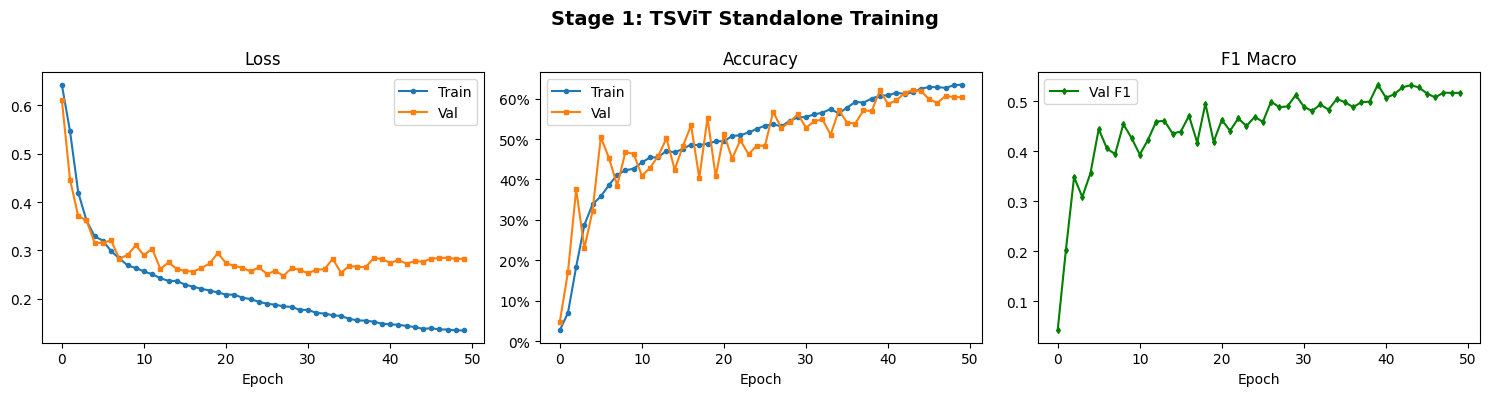

In [10]:
# ============================================================
# Celda 10: Curvas de entrenamiento Stage 1
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_s1['train_loss'], label='Train', marker='o', markersize=3)
axes[0].plot(history_s1['val_loss'], label='Val', marker='s', markersize=3)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history_s1['train_acc'], label='Train', marker='o', markersize=3)
axes[1].plot(history_s1['val_acc'], label='Val', marker='s', markersize=3)
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

axes[2].plot(history_s1['val_f1'], label='Val F1', marker='d', markersize=3, color='green')
axes[2].set_title('F1 Macro'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('Stage 1: TSViT Standalone Training', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 🔗 Stage 2: Conectar TSViT → Projector → LLM (LoRA)

**Componentes:**
1. **TSViT** (frozen) — usa los pesos de Stage 1
2. **Projector** (Adapter, trainable) — MLP 2 capas: `dim → llm_dim → llm_dim`
3. **LLM** (Qwen2.5-3B, 4-bit + LoRA) — genera texto

**Prompt template:**
```
<|im_start|>system
You classify crops from satellite time series features.<|im_end|>
<|im_start|>user
[VISUAL TOKENS FROM TSVIT]
What crop is shown in this satellite image time series?<|im_end|>
<|im_start|>assistant
{crop_name}<|im_end|>
```

In [11]:
# ============================================================
# Celda 11: Projector (Adapter) y modelo TSViT-LLM
# ============================================================
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType

class Projector(nn.Module):
    """MLP Projector: TSViT dim → LLM dim (LLaVA pattern)."""
    def __init__(self, tsvit_dim, llm_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(tsvit_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim),
        )
    def forward(self, x):
        return self.mlp(x)

class TSViTLLM(nn.Module):
    """
    TSViT encoder (frozen) → Projector (trainable) → LLM decoder (LoRA).
    """
    def __init__(self, tsvit, llm_name, tsvit_dim=128):
        super().__init__()
        
        # ── TSViT encoder (FROZEN) ──
        self.tsvit = tsvit
        for p in self.tsvit.parameters():
            p.requires_grad = False
        self.tsvit.eval()
        
      
        print(f"  Cargando {llm_name} en bf16...")
        self.llm = AutoModelForCausalLM.from_pretrained(
            llm_name,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )
        self.tokenizer = AutoTokenizer.from_pretrained(llm_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = "right"
        
        # ── LoRA ──
        print("  Aplicando LoRA...")
        lora_config = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=16, lora_alpha=32, lora_dropout=0.05,
            target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
        )
        self.llm = get_peft_model(self.llm, lora_config)
        
        # ── Projector ──
        llm_dim = self.llm.config.hidden_size
        self.projector = Projector(tsvit_dim, llm_dim).to(
            dtype=torch.bfloat16, device=self.llm.device
        )
        
        print(f"  ✅ LLM hidden_size: {llm_dim}")
        self.llm.print_trainable_parameters()
    
    def _get_text_embeddings(self, text_list):
        """Tokeniza y obtiene embeddings de texto."""
        tokens = self.tokenizer(text_list, return_tensors="pt", padding=True,
                                truncation=True, max_length=64)
        tokens = {k: v.to(self.llm.device) for k, v in tokens.items()}
        embeds = self.llm.get_input_embeddings()(tokens['input_ids'])
        return embeds, tokens['attention_mask'], tokens['input_ids']
    
    def forward(self, sits, prompt_text, answer_text):
        """
        sits: (B, T, 11, H, W)
        prompt_text: list[str]
        answer_text: list[str] — con EOS token al final
        Returns: loss (scalar)
        """
        B = sits.size(0)
        
        # ── 1. TSViT features (frozen) ──
        with torch.no_grad():
            cls_features = self.tsvit(sits)  # (B, K, tsvit_dim)
        
        # ── 2. Project a LLM space ──
        visual_tokens = self.projector(cls_features.to(torch.bfloat16))
        visual_tokens = visual_tokens.to(self.llm.device)
        
        # ── 3. Tokenizar prompt y answer ──
        prompt_embeds, prompt_mask, _ = self._get_text_embeddings(prompt_text)
        answer_embeds, answer_mask, answer_ids = self._get_text_embeddings(answer_text)
        
        # ── 4. Concatenar: [visual | prompt | answer] ──
        all_embeds = torch.cat([visual_tokens, prompt_embeds, answer_embeds], dim=1)
        
        visual_mask = torch.ones(B, visual_tokens.size(1),
                                  device=self.llm.device, dtype=torch.long)
        all_mask = torch.cat([visual_mask, prompt_mask, answer_mask], dim=1)
        
        # ── 5. Labels: -100 para visual+prompt, real para answer ──
        ignore_len = visual_tokens.size(1) + prompt_embeds.size(1)
        ignore_labels = torch.full((B, ignore_len), -100,
                                    device=self.llm.device, dtype=torch.long)
        
        answer_labels = answer_ids.clone()
        answer_labels[answer_mask == 0] = -100
        
        labels = torch.cat([ignore_labels, answer_labels], dim=1)
        
        # ── 6. LLM forward ──
        outputs = self.llm(inputs_embeds=all_embeds,
                           attention_mask=all_mask, labels=labels)
        
        return outputs.loss
    
    @torch.no_grad()
    def generate(self, sits, prompt_text, max_new_tokens=32):
        """Genera prediccion de cultivo."""
        self.tsvit.eval()
        B = sits.size(0)
        
        cls_features = self.tsvit(sits)
        visual_tokens = self.projector(cls_features.to(torch.bfloat16))
        visual_tokens = visual_tokens.to(self.llm.device)
        
        prompt_embeds, prompt_mask, _ = self._get_text_embeddings(prompt_text)
        
        input_embeds = torch.cat([visual_tokens, prompt_embeds], dim=1)
        visual_mask = torch.ones(B, visual_tokens.size(1),
                                  device=self.llm.device, dtype=torch.long)
        attn_mask = torch.cat([visual_mask, prompt_mask], dim=1)
        
        outputs = self.llm.generate(
            inputs_embeds=input_embeds,
            attention_mask=attn_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=self.tokenizer.pad_token_id,
        )
        
        texts = self.tokenizer.batch_decode(outputs, skip_special_tokens=True)
        return texts

In [15]:
# ============================================================
# Celda 12: Instanciar TSViT-LLM
# ============================================================

# Cargar mejores pesos de Stage 1
tsvit.load_state_dict(torch.load("tsvit_best.pt", map_location=DEVICE))
print("✅ TSViT cargado con pesos de Stage 1")

# Limpiar VRAM de Stage 1 (seguro si ya se borraron)
for var_name in ['classifier', 'optimizer_s1', 'scheduler_s1', 'scaler']:
    if var_name in globals():
        del globals()[var_name]
gc.collect()
torch.cuda.empty_cache()

# Crear modelo completo
model = TSViTLLM(tsvit, LLM_NAME, tsvit_dim=DIM)

# Prompt template
PROMPT = "What crop is shown in this satellite image time series? Answer with just the crop name."

# Answer mapping — incluye EOS para que el modelo aprenda a parar
def make_answer(label_id):
    name = CLASSES[label_id + 1]  # 1-indexed
    return name.replace("_", " ").lower() + model.tokenizer.eos_token

# Test rapido
test_answer = make_answer(0)
print(f"  Ejemplo answer: '{test_answer}'")
print(f"  EOS token: '{model.tokenizer.eos_token}'")

if DEVICE == "cuda":
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"\n📊 VRAM: {allocated:.1f} GB allocated / {reserved:.1f} GB reserved")

✅ TSViT cargado con pesos de Stage 1
  Cargando Qwen/Qwen2.5-3B-Instruct en bf16...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Aplicando LoRA...
  ✅ LLM hidden_size: 2048
trainable params: 7,372,800 || all params: 3,093,311,488 || trainable%: 0.2383
  Ejemplo answer: 'meadow<|im_end|>'
  EOS token: '<|im_end|>'

📊 VRAM: 6.3 GB allocated / 6.4 GB reserved


In [16]:
# ============================================================
# Celda 13: Training loop Stage 2 — Projector + LoRA
# Ref: LLaVA (Liu et al. 2023) — two-stage training
# ============================================================

# Optimizer con LR diferenciado: projector más alto, LoRA más conservador
optimizer_s2 = torch.optim.AdamW([
    {'params': model.projector.parameters(), 'lr': LR_PROJECTOR},
    {'params': [p for p in model.llm.parameters() if p.requires_grad], 'lr': LR_LORA},
], weight_decay=0.01)

scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_s2, T_max=NUM_EPOCHS_STAGE2
)

print(f"\n{'='*60}")
print(f"STAGE 2: Entrenando Projector + LoRA")
print(f"{'='*60}")
print(f"  Projector LR: {LR_PROJECTOR}")
print(f"  LoRA LR: {LR_LORA}")
print(f"  Epochs: {NUM_EPOCHS_STAGE2}")

projector_params = sum(p.numel() for p in model.projector.parameters())
lora_params = sum(p.numel() for p in model.llm.parameters() if p.requires_grad)
print(f"  Projector params: {projector_params:,}")
print(f"  LoRA params: {lora_params:,}")

history_s2 = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_acc_s2 = 0

for epoch in range(NUM_EPOCHS_STAGE2):
    # ── Train ──
    model.tsvit.eval()
    model.llm.train()
    model.projector.train()
    
    total_loss, n_batches = 0, 0
    pbar = tqdm(train_loader, desc=f"S2 Ep{epoch+1}", leave=False)
    
    optimizer_s2.zero_grad()
    for i, batch in enumerate(pbar):
        sits = batch['sits'].to(DEVICE, non_blocking=True)
        labels = batch['label']
        
        prompts = [PROMPT] * sits.size(0)
        answers = [make_answer(l.item()) for l in labels]
        
        with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
            loss = model(sits, prompts, answers)
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(
            list(model.projector.parameters()) +
            [p for p in model.llm.parameters() if p.requires_grad], 1.0
        )
        optimizer_s2.step()
        optimizer_s2.zero_grad()
        
        total_loss += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_train_loss = total_loss / max(n_batches, 1)
    
    # ── Eval: generar y comparar texto ──
    model.eval()
    all_preds, all_labels = [], []
    eval_loss = 0
    n_eval = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Val", leave=False):
            sits = batch['sits'].to(DEVICE, non_blocking=True)
            labels = batch['label']
            
            prompts = [PROMPT] * sits.size(0)
            
            # Loss
            answers = [make_answer(l.item()) for l in labels]
            with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
                loss = model(sits, prompts, answers)
            eval_loss += loss.item()
            n_eval += 1
            
            # Generate predictions
            texts = model.generate(sits, prompts, max_new_tokens=16)
            
            # Matchear texto generado con clases
            for text, label in zip(texts, labels):
                text_clean = text.strip().lower()
                pred_class = -1
                for cls_id, cls_name in CLASSES.items():
                    if cls_name.replace("_", " ").lower() in text_clean:
                        pred_class = cls_id - 1  # 0-indexed
                        break
                all_preds.append(pred_class)
                all_labels.append(label.item())
    
    avg_val_loss = eval_loss / max(n_eval, 1)
    
    # Accuracy solo sobre predicciones validas (matched)
    valid = [(p, l) for p, l in zip(all_preds, all_labels) if p >= 0]
    if valid:
        vp, vl = zip(*valid)
        val_acc = accuracy_score(vl, vp)
        val_f1 = f1_score(vl, vp, average='macro', zero_division=0)
        match_rate = len(valid) / len(all_preds)
    else:
        val_acc, val_f1, match_rate = 0, 0, 0
    
    scheduler_s2.step()
    
    history_s2['train_loss'].append(avg_train_loss)
    history_s2['val_loss'].append(avg_val_loss)
    history_s2['val_acc'].append(val_acc)
    history_s2['val_f1'].append(val_f1)
    
    improved = ""
    if val_acc > best_val_acc_s2:
        best_val_acc_s2 = val_acc
        torch.save({
            'projector': model.projector.state_dict(),
            'lora': model.llm.state_dict(),
        }, "tsvit_llm_best.pt")
        improved = " ⭐ best"
    
    lr_now = scheduler_s2.get_last_lr()[0]
    print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS_STAGE2} | "
          f"Train loss={avg_train_loss:.4f} | "
          f"Val loss={avg_val_loss:.4f} acc={val_acc:.1%} F1={val_f1:.3f} | "
          f"Match={match_rate:.0%} LR={lr_now:.1e}{improved}")

print(f"\n✅ Best Stage 2 val accuracy: {best_val_acc_s2:.1%}")


STAGE 2: Entrenando Projector + LoRA
  Projector LR: 0.001
  LoRA LR: 0.0002
  Epochs: 15
  Projector params: 4,460,544
  LoRA params: 7,372,800


S2 Ep1:   0%|          | 0/511 [00:00<?, ?it/s]

Val:   0%|          | 0/169 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Epoch  1/15 | Train loss=0.4133 | Val loss=0.2435 acc=77.7% F1=0.621 | Match=100% LR=9.9e-04 ⭐ best


...

Val:   0%|          | 0/169 [00:00<?, ?it/s]

  Epoch 14/15 | Train loss=0.1477 | Val loss=0.2216 acc=78.8% F1=0.644 | Match=100% LR=1.1e-05


S2 Ep15:   0%|          | 0/511 [00:00<?, ?it/s]

Val:   0%|          | 0/169 [00:00<?, ?it/s]

  Epoch 15/15 | Train loss=0.1483 | Val loss=0.2214 acc=78.9% F1=0.645 | Match=100% LR=0.0e+00

✅ Best Stage 2 val accuracy: 79.0%


✅ Cargados mejores pesos de Stage 2

EVALUACIÓN FINAL — Test Set (11,124 samples)


Test:   0%|          | 0/174 [00:00<?, ?it/s]


📊 Match rate: 11124/11124 (100.0%)

 Test Accuracy (matched): 76.8%
   Test F1 Macro (matched): 0.622

                           precision    recall  f1-score   support

                   meadow       0.81      0.87      0.84      4308
        soft winter wheat       0.83      0.79      0.81      1366
                     corn       0.85      0.81      0.83      1540
            winter barley       0.71      0.71      0.71       413
          winter rapeseed       0.80      0.76      0.78       351
            spring barley       0.60      0.62      0.61       156
                sunflower       0.66      0.68      0.67       266
                grapevine       0.81      0.84      0.83       801
                     beet       0.79      0.74      0.76       154
         winter triticale       0.43      0.30      0.35       134
       winter durum wheat       0.53      0.72      0.61       280
fruits vegetables flowers       0.49      0.32      0.38       253
                 potatoe

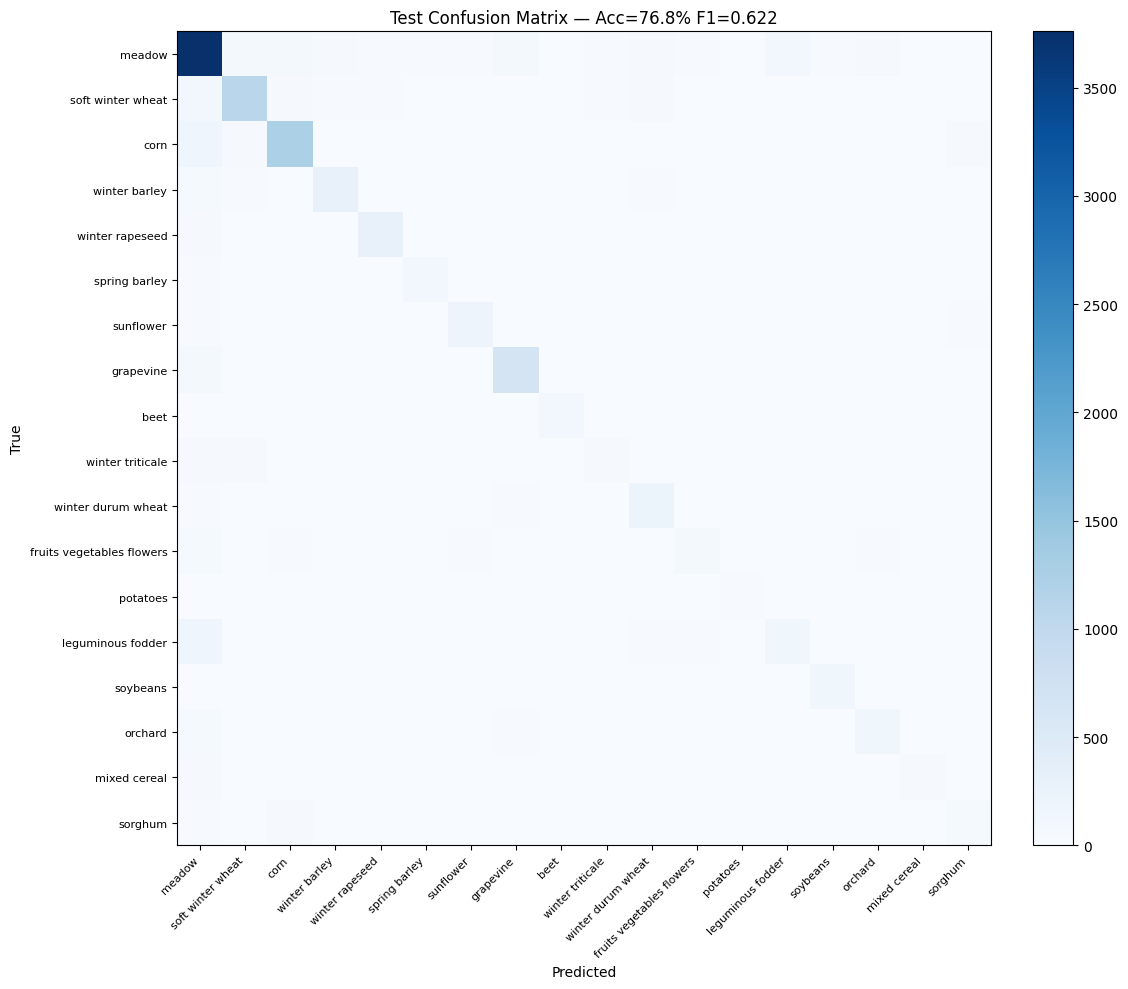

In [17]:
# ============================================================
# Celda 14: Evaluación final en Test Set
# ============================================================

# Cargar mejores pesos de Stage 2
best_ckpt = torch.load("tsvit_llm_best.pt", map_location=DEVICE)
model.projector.load_state_dict(best_ckpt['projector'])
model.llm.load_state_dict(best_ckpt['lora'], strict=False)
print("✅ Cargados mejores pesos de Stage 2")

model.eval()
all_preds, all_labels, all_texts = [], [], []
CLASS_NAMES = {k: v.replace("_", " ").lower() for k, v in CLASSES.items()}
# Reverso: texto → clase 0-indexed
NAME_TO_IDX = {v: k - 1 for k, v in CLASS_NAMES.items()}

print(f"\n{'='*60}")
print(f"EVALUACIÓN FINAL — Test Set ({len(test_data):,} samples)")
print(f"{'='*60}")

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        sits = batch['sits'].to(DEVICE, non_blocking=True)
        labels = batch['label']
        
        prompts = [PROMPT] * sits.size(0)
        
        with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
            texts = model.generate(sits, prompts, max_new_tokens=16)
        
        for text, label in zip(texts, labels):
            text_clean = text.strip().lower()
            pred_class = -1
            # Buscar match mas largo primero (evita "wheat" matcheando antes que "soft winter wheat")
            for cls_name, cls_idx in sorted(NAME_TO_IDX.items(), key=lambda x: -len(x[0])):
                if cls_name in text_clean:
                    pred_class = cls_idx
                    break
            
            all_preds.append(pred_class)
            all_labels.append(label.item())
            all_texts.append(text_clean)

# ── Métricas ──
total = len(all_labels)
matched = sum(1 for p in all_preds if p >= 0)
unmatched_texts = [t for p, t in zip(all_preds, all_texts) if p < 0]

print(f"\n📊 Match rate: {matched}/{total} ({matched/total:.1%})")
if unmatched_texts:
    from collections import Counter as Ctr
    print(f"   Top textos no matcheados:")
    for txt, cnt in Ctr(unmatched_texts).most_common(10):
        print(f"     '{txt}' (x{cnt})")

# Accuracy y F1 sobre matcheados
valid = [(p, l) for p, l in zip(all_preds, all_labels) if p >= 0]
if valid:
    vp, vl = zip(*valid)
    test_acc = accuracy_score(vl, vp)
    test_f1 = f1_score(vl, vp, average='macro', zero_division=0)
    
    print(f"\n Test Accuracy (matched): {test_acc:.1%}")
    print(f"   Test F1 Macro (matched): {test_f1:.3f}")
    
    # Classification report
    labels_present = sorted(set(vl) | set(vp))
    target_names = [CLASS_NAMES.get(i + 1, f"cls_{i}") for i in labels_present]
    print(f"\n{classification_report(vl, vp, labels=labels_present, target_names=target_names, zero_division=0)}")
    
    # Confusion matrix
    cm = confusion_matrix(vl, vp, labels=list(range(NUM_CLASSES)))
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    class_labels = [CLASS_NAMES.get(i + 1, f"{i}") for i in range(NUM_CLASSES)]
    ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
           xticklabels=class_labels, yticklabels=class_labels,
           ylabel='True', xlabel='Predicted',
           title=f'Test Confusion Matrix — Acc={test_acc:.1%} F1={test_f1:.3f}')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Ninguna predicción matcheó con clases conocidas")

🔍 Visualizando predicciones aleatorias del test set...



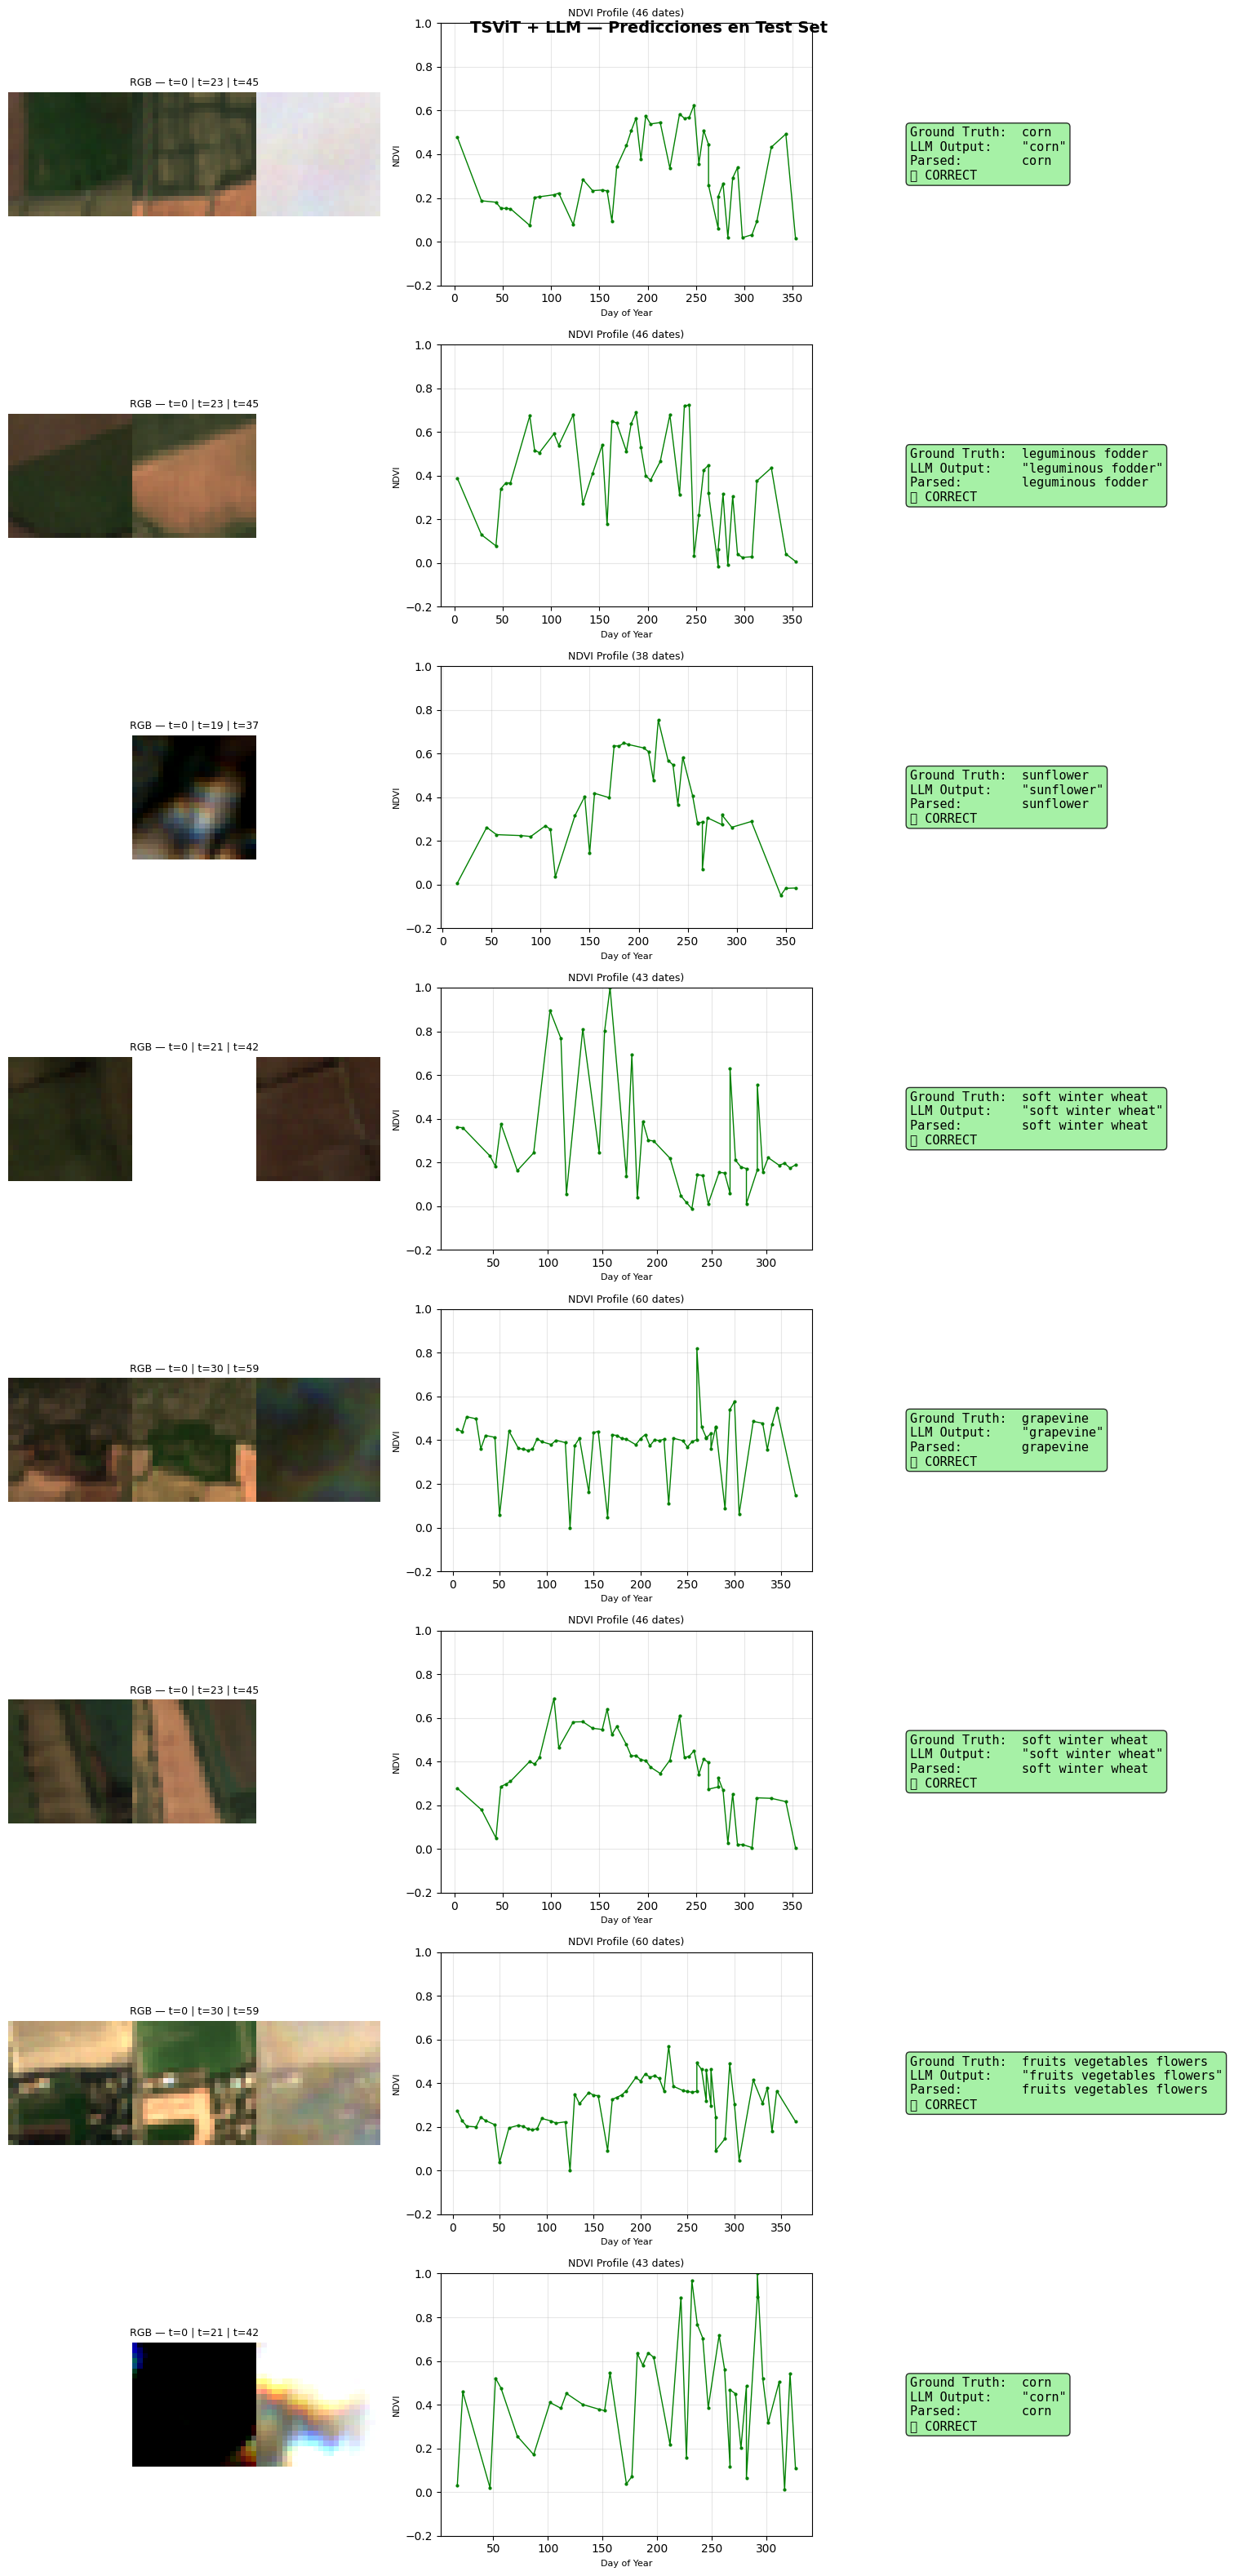

In [18]:
# ============================================================
# Celda 15: Visualización de prediccion
# ============================================================

def visualize_predictions(model, dataset, samples_idx=None, n_samples=8):
    """
    Muestra para cada sample:
    - RGB compuesto (3 timestamps: inicio, medio, fin)
    - NDVI temporal profile
    - Predicción del LLM vs ground truth
    """
    model.eval()
    
    if samples_idx is None:
        samples_idx = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    
    n = len(samples_idx)
    fig, axes = plt.subplots(n, 3, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[None, :]
    
    for row, idx in enumerate(samples_idx):
        sample = dataset[idx]
        sits = sample['sits'].unsqueeze(0).to(DEVICE)  # (1, T, 11, 24, 24)
        label = sample['label'].item()
        true_name = CLASS_NAMES.get(label + 1, f"cls_{label}")
        T = sample['seq_len'].item()
        
        # ── Generar predicción ──
        with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
            pred_text = model.generate(sits, [PROMPT], max_new_tokens=16)[0]
        pred_clean = pred_text.strip().lower()
        
        # Matching
        pred_name = "???"
        for cls_name, cls_idx in sorted(NAME_TO_IDX.items(), key=lambda x: -len(x[0])):
            if cls_name in pred_clean:
                pred_name = cls_name
                break
        
        correct = pred_name == true_name
        color = 'green' if correct else 'red'
        
        # ── Col 0: RGB compuesto (3 timestamps) ──
        sits_np = sample['sits'].numpy()  # (T, 11, 24, 24)
        t_indices = [0, T // 2, T - 1]
        rgb_mosaic = []
        
        for t in t_indices:
            if t < sits_np.shape[0]:
                # Bandas espectrales: canal 1=B2(blue), 2=B3(green), 3=B4(red)
                r = sits_np[t, 3]  # B4 - Red
                g = sits_np[t, 2]  # B3 - Green
                b = sits_np[t, 1]  # B2 - Blue
                rgb = np.stack([r, g, b], axis=-1)
                rgb = np.clip(rgb * 3.5, 0, 1)  # brightness boost
                rgb_mosaic.append(rgb)
        
        if rgb_mosaic:
            mosaic = np.concatenate(rgb_mosaic, axis=1)  # (24, 72, 3)
            axes[row, 0].imshow(mosaic)
            axes[row, 0].set_title(f"RGB — t=0 | t={T//2} | t={T-1}", fontsize=9)
        axes[row, 0].axis('off')
        
        # ── Col 1: NDVI temporal ──
        # NDVI = (NIR - Red) / (NIR + Red) = (B8 - B4) / (B8 + B4)
        # B8 = canal 7 (index 0-based en 10 bandas) → sits canal 8 (con time ch)
        # B4 = canal 3 → sits canal 4
        nir = sits_np[:T, 8, :, :].mean(axis=(1, 2))  # B8 - NIR
        red = sits_np[:T, 4, :, :].mean(axis=(1, 2))   # B4 - Red
        ndvi = (nir - red) / (nir + red + 1e-8)
        
        # Day of year del canal temporal
        doy = sits_np[:T, 0, 0, 0] * 365
        
        axes[row, 1].plot(doy, ndvi, 'g-o', markersize=2, linewidth=1)
        axes[row, 1].set_ylim(-0.2, 1.0)
        axes[row, 1].set_xlabel('Day of Year', fontsize=8)
        axes[row, 1].set_ylabel('NDVI', fontsize=8)
        axes[row, 1].set_title(f'NDVI Profile ({T} dates)', fontsize=9)
        axes[row, 1].grid(True, alpha=0.3)
        
        # ── Col 2: Predicción ──
        axes[row, 2].axis('off')
        info_text = (
            f"Ground Truth:  {true_name}\n"
            f"LLM Output:    \"{pred_clean}\"\n"
            f"Parsed:        {pred_name}\n"
            f"{'✅ CORRECT' if correct else '❌ WRONG'}"
        )
        axes[row, 2].text(0.1, 0.5, info_text, transform=axes[row, 2].transAxes,
                          fontsize=11, verticalalignment='center', fontfamily='monospace',
                          bbox=dict(boxstyle='round', facecolor='lightgreen' if correct else 'lightyellow',
                                    alpha=0.8))
    
    plt.suptitle('TSViT + LLM — Predicciones en Test Set', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return samples_idx

# ── Ejecutar: 8 samples aleatorios del test set ──
print("🔍 Visualizando predicciones aleatorias del test set...\n")
used_idx = visualize_predictions(model, test_ds, n_samples=8)

## Resumen

### Arquitectura implementada
- **Encoder**: TSViT (Temporal-Spatial ViT, CVPR 2023) — 6 capas temporales + 2 espaciales
- **Projector**: MLP 2 capas (128 -> LLM dim) — patron LLaVA
- **Decoder**: Qwen2.5-3B-Instruct (4-bit + LoRA r=16)

### Dataset: PASTIS24
- Formato pre-procesado del repo DeepSatModels
- `pickle24x24/` con ~60K ventanas 24x24
- 5-fold split oficial en `fold-paths/`
- Folds 1-3: train, Fold 4: val, Fold 5: test

### Entrenamiento en 2 etapas
1. Stage 1: TSViT standalone con Focal Loss (encoder aprende features)

### Fuentes verificadas
| Componente | Referencia |
|-----------|-----------|
| TSViT | Tarasiou et al., CVPR 2023 |
| PASTIS / PASTIS24 | Garnot & Landrieu, 2022 |
| Projector MLP | Liu et al., LLaVA, NeurIPS 2023 |
| LoRA | Hu et al., ICLR 2022 |
| Focal Loss | Lin et al., ICCV 2017 |